# Capítulo 1 — El grupo P de aplicaciones lineales

> **Referencia:** Vega Penagos, C. A. & Olivero Zapata, H. A. (2015).
> *Implementación en software de aplicaciones conformes*, Capítulo 1.
> Universidad del Tolima.

Este notebook reproduce las **Figuras 1.1, 1.2 y 1.3** de la tesis usando la
implementación Python del grupo P, y verifica numéricamente los **Teoremas 1
a 6** y el **Corolario 1**.

El grupo P es el conjunto de aplicaciones lineales $\mathbb{R}^2 \to \mathbb{R}^2$
que preservan ángulos. La tesis prueba (Teorema 5) que P está generado por
tres familias:

- **Rotaciones** $R(\theta)$ — Teorema 2
- **Reflexiones** $\mathrm{Ref}(\theta)$ — Teorema 3
- **Dilataciones** $D(\lambda)$ con $\lambda \in \mathbb{R} \setminus \{0\}$ — Teorema 4

y que estas tres familias forman un grupo bajo composición (Teorema 6).


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from pyconformal.linear import Rotation, Reflection, Dilation

# Configuración estética común
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.alpha": 0.3,
    }
)

## §1.1 — Rotación: Figura 1.1 de la tesis

La matriz de rotación es

$$R(\theta) = \begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix}.$$

Aplicada a un vector $A = (x_1, y_1)$ produce el vector rotado $A' = R(\theta) A$.


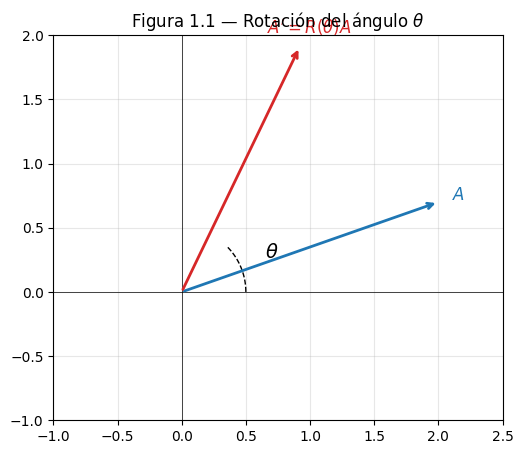

In [2]:
def plot_vector(ax, v, color, label, origin=(0, 0)):
    ax.annotate(
        "",
        xy=(origin[0] + v[0], origin[1] + v[1]),
        xytext=origin,
        arrowprops={"arrowstyle": "->", "color": color, "lw": 2},
    )
    ax.text(
        origin[0] + v[0] * 1.08,
        origin[1] + v[1] * 1.08,
        label,
        color=color,
        fontsize=12,
        ha="center",
        va="center",
    )


def reproduce_figure_1_1(theta=np.pi / 4):
    A = np.array([2.0, 0.7])
    R = Rotation(theta)
    A_prime = R.matrix @ A

    _fig, ax = plt.subplots()
    plot_vector(ax, A, "tab:blue", r"$A$")
    plot_vector(ax, A_prime, "tab:red", r"$A' = R(\theta) A$")

    # Arco indicando el ángulo
    arc_t = np.linspace(0, theta, 50)
    r_arc = 0.5
    ax.plot(r_arc * np.cos(arc_t), r_arc * np.sin(arc_t), "k--", lw=1)
    ax.text(0.7 * np.cos(theta / 2), 0.7 * np.sin(theta / 2), r"$\theta$", fontsize=14)

    ax.set_xlim(-1, 2.5)
    ax.set_ylim(-1, 2.0)
    ax.set_aspect("equal")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_title(r"Figura 1.1 — Rotación del ángulo $\theta$")
    plt.show()


reproduce_figure_1_1(theta=np.pi / 4)

### Verificación numérica del Teorema 2

Una rotación preserva ángulos entre vectores. Lo comprobamos numéricamente
sobre 64 pares aleatorios:


In [3]:
R = Rotation(0.73)
print(f"R(0.73).is_orthogonal()       = {R.is_orthogonal()}")
print(f"R(0.73).det                   = {R.det:.16f}")
print(f"R(0.73).preserves_orientation = {R.preserves_orientation}")
print(f"R(0.73).preserves_angles()    = {R.preserves_angles()}")

R(0.73).is_orthogonal()       = True
R(0.73).det                   = 1.0000000000000000
R(0.73).preserves_orientation = True
R(0.73).preserves_angles()    = True


## §1.1 — Reflexión: Figura 1.2 de la tesis

La matriz de reflexión es

$$\mathrm{Ref}(\theta) = \begin{pmatrix}
\cos\theta & \sin\theta \\
\sin\theta & -\cos\theta
\end{pmatrix}.$$

Geométricamente refleja a través de la recta por el origen que hace ángulo
$\theta/2$ con el eje $x$ positivo.


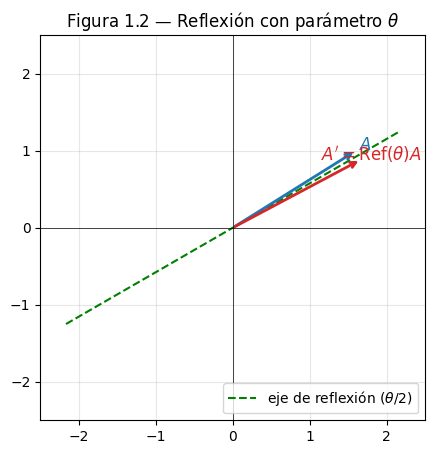

In [4]:
def reproduce_figure_1_2(theta=np.pi / 3):
    A = np.array([1.6, 1.0])
    Ref = Reflection(theta)
    A_prime = Ref.matrix @ A

    _fig, ax = plt.subplots()
    plot_vector(ax, A, "tab:blue", r"$A$")
    plot_vector(ax, A_prime, "tab:red", r"$A' = \mathrm{Ref}(\theta) A$")

    # Recta de reflexión (en ángulo θ/2 con el eje x)
    axis_angle = theta / 2
    line_t = np.linspace(-2.5, 2.5, 2)
    ax.plot(
        line_t * np.cos(axis_angle),
        line_t * np.sin(axis_angle),
        "g--",
        lw=1.5,
        label=r"eje de reflexión ($\theta / 2$)",
    )

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect("equal")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", lw=0.5)
    ax.legend(loc="lower right")
    ax.set_title(r"Figura 1.2 — Reflexión con parámetro $\theta$")
    plt.show()


reproduce_figure_1_2(theta=np.pi / 3)

### Verificación numérica del Teorema 3 y la involución

Una reflexión es **su propia inversa**: $\mathrm{Ref}(\theta) \circ \mathrm{Ref}(\theta) = I$.


In [5]:
Ref = Reflection(0.6)
print(f"Ref(0.6).is_orthogonal()       = {Ref.is_orthogonal()}")
print(f"Ref(0.6).det                   = {Ref.det:.16f}")
print(f"Ref(0.6).preserves_orientation = {Ref.preserves_orientation}")
print(f"Ref(0.6).preserves_angles()    = {Ref.preserves_angles()}")
print()
print(f"(Ref ∘ Ref).is_identity()      = {(Ref @ Ref).is_identity()}")

Ref(0.6).is_orthogonal()       = True
Ref(0.6).det                   = -1.0000000000000000
Ref(0.6).preserves_orientation = False
Ref(0.6).preserves_angles()    = True

(Ref ∘ Ref).is_identity()      = True


## §1.1 — Dilatación: Figura 1.3 de la tesis

La matriz de dilatación es

$$D(\lambda) = \begin{pmatrix} \lambda & 0 \\ 0 & \lambda \end{pmatrix},
\quad \lambda \in \mathbb{R} \setminus \{0\}.$$

Multiplica todas las longitudes por $|\lambda|$ pero **preserva ángulos**
(Teorema 4). Para $\lambda < 0$ es equivalente a una dilatación por $|\lambda|$
seguida de una rotación de $\pi$.


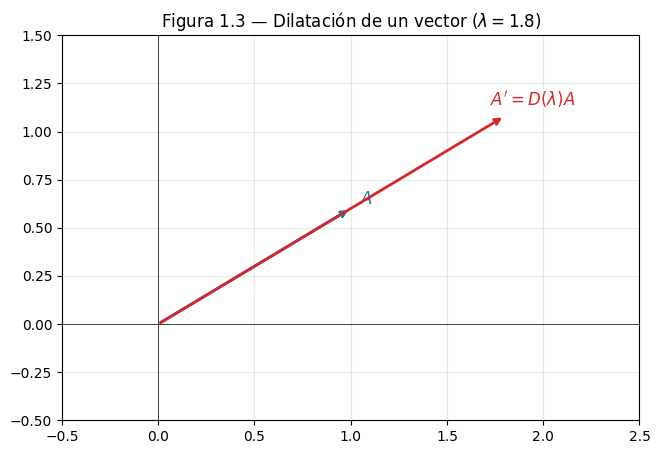

In [6]:
def reproduce_figure_1_3(lam=1.8):
    A = np.array([1.0, 0.6])
    D = Dilation(lam)
    A_prime = D.matrix @ A

    _fig, ax = plt.subplots()
    plot_vector(ax, A, "tab:blue", r"$A$")
    plot_vector(ax, A_prime, "tab:red", r"$A' = D(\lambda) A$")

    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_aspect("equal")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_title(rf"Figura 1.3 — Dilatación de un vector ($\lambda = {lam}$)")
    plt.show()


reproduce_figure_1_3(lam=1.8)

In [7]:
D = Dilation(1.8)
print(f"D(1.8).is_orthogonal()        = {D.is_orthogonal()}  (False: dilatación no es ortogonal)")
print(f"D(1.8).det                    = {D.det}  (= λ² siempre)")
print(f"D(1.8).preserves_orientation  = {D.preserves_orientation}")
print(f"D(1.8).preserves_angles()     = {D.preserves_angles()}")

D(1.8).is_orthogonal()        = False  (False: dilatación no es ortogonal)
D(1.8).det                    = 3.24  (= λ² siempre)
D(1.8).preserves_orientation  = True
D(1.8).preserves_angles()     = True


## Teorema 6: el grupo P bajo composición

La tesis demuestra el cierre del grupo P enumerando **siete casos**. Vamos a
verificar numéricamente cada uno con parámetros arbitrarios.


In [8]:
# Caso 1: Rotación ∘ Rotación = Rotación
alpha, beta = 0.3, 0.7
r = Rotation(alpha) @ Rotation(beta)
print(f"Caso 1: R(0.3) @ R(0.7) = {r!r}")
print(f"        ¿igual a R(1.0)? {r.equals(Rotation(alpha + beta))}")

# Caso 2: Reflexión ∘ Reflexión = Rotación
r = Reflection(0.5) @ Reflection(0.2)
print(f"\nCaso 2: Ref(0.5) @ Ref(0.2) = {r!r}")
print(f"        ¿igual a R(0.3)? {r.equals(Rotation(0.5 - 0.2))}")

# Caso 3: Dilatación ∘ Dilatación = Dilatación
r = Dilation(2.0) @ Dilation(3.0)
print(f"\nCaso 3: D(2) @ D(3) = {r!r}")
print(f"        ¿igual a D(6)? {r.equals(Dilation(6.0))}")

# Caso 4: Rotación ∘ Reflexión = Reflexión
r = Rotation(0.3) @ Reflection(0.7)
print(f"\nCaso 4: R(0.3) @ Ref(0.7) = {r!r}")
print(f"        ¿igual a Ref(1.0)? {r.equals(Reflection(1.0))}")

# Caso 5: Reflexión ∘ Rotación = Reflexión
r = Reflection(0.5) @ Rotation(0.2)
print(f"\nCaso 5: Ref(0.5) @ R(0.2) = {r!r}")
print(f"        ¿igual a Ref(0.3)? {r.equals(Reflection(0.3))}")

# Caso 6: Dilatación ∘ Rotación = rotación escalada
r = Dilation(2.0) @ Rotation(np.pi / 4)
print(
    f"\nCaso 6: D(2) @ R(π/4) → tipo {type(r).__name__}, preserva ángulos = {r.preserves_angles()}"
)

# Caso 7: D y R conmutan
a = Dilation(2.0) @ Rotation(np.pi / 4)
b = Rotation(np.pi / 4) @ Dilation(2.0)
print(f"\nCaso 7: D ∘ R = R ∘ D → equals = {a.equals(b)}")

Caso 1: R(0.3) @ R(0.7) = Rotation(theta=1.0)
        ¿igual a R(1.0)? True

Caso 2: Ref(0.5) @ Ref(0.2) = Rotation(theta=0.3)
        ¿igual a R(0.3)? True

Caso 3: D(2) @ D(3) = Dilation(lambda_=6.0)
        ¿igual a D(6)? True

Caso 4: R(0.3) @ Ref(0.7) = Reflection(theta=1.0)
        ¿igual a Ref(1.0)? True

Caso 5: Ref(0.5) @ R(0.2) = Reflection(theta=0.3)
        ¿igual a Ref(0.3)? True

Caso 6: D(2) @ R(π/4) → tipo LinearMap, preserva ángulos = True

Caso 7: D ∘ R = R ∘ D → equals = True


## Visualización del cierre: una composición arbitraria preserva ángulos

Aplicamos una composición $D(\lambda) \circ R(\theta) \circ \mathrm{Ref}(\phi)$
a una cuadrícula y verificamos visualmente que las líneas perpendiculares
del dominio se mapean a líneas perpendiculares en la imagen (preservación
de ángulos).


Composición M = D(1.2) @ R(π/5) @ Ref(0.3)
  tipo: LinearMap
  det:  -1.4400  (negativo: invierte orientación)
  preserva ángulos: True


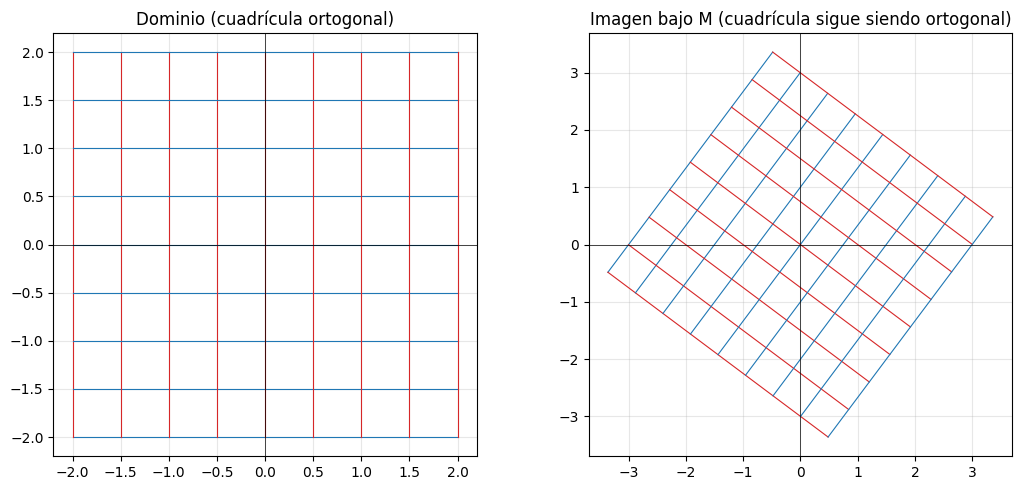

In [9]:
def plot_grid_under(M, ax_left, ax_right, n=8, extent=2.0):
    ts = np.linspace(-extent, extent, n)
    # Líneas horizontales y verticales en azul/rojo respectivamente
    for t in ts:
        # Horizontal y = t
        xs = np.linspace(-extent, extent, 100)
        zs = xs + 1j * t
        ax_left.plot(zs.real, zs.imag, "tab:blue", lw=0.8)
        ws = M(zs)
        ax_right.plot(ws.real, ws.imag, "tab:blue", lw=0.8)
        # Vertical x = t
        ys = np.linspace(-extent, extent, 100)
        zs = t + 1j * ys
        ax_left.plot(zs.real, zs.imag, "tab:red", lw=0.8)
        ws = M(zs)
        ax_right.plot(ws.real, ws.imag, "tab:red", lw=0.8)

    for ax in (ax_left, ax_right):
        ax.set_aspect("equal")
        ax.axhline(0, color="black", lw=0.5)
        ax.axvline(0, color="black", lw=0.5)


M = Dilation(1.2) @ Rotation(np.pi / 5) @ Reflection(0.3)
print("Composición M = D(1.2) @ R(π/5) @ Ref(0.3)")
print(f"  tipo: {type(M).__name__}")
print(f"  det:  {M.det:+.4f}  (negativo: invierte orientación)")
print(f"  preserva ángulos: {M.preserves_angles()}")

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 5))
plot_grid_under(M, ax_left, ax_right, n=9, extent=2.0)
ax_left.set_title("Dominio (cuadrícula ortogonal)")
ax_right.set_title("Imagen bajo M (cuadrícula sigue siendo ortogonal)")
plt.tight_layout()
plt.show()

## Corolario 1 — Subgrupos de P

Las rotaciones y las dilataciones forman cada una un **subgrupo** de P,
porque la composición de dos rotaciones es una rotación (Caso 1) y la
composición de dos dilataciones es una dilatación (Caso 3).

Las **reflexiones no** forman un subgrupo: la composición de dos reflexiones
es una rotación (Caso 2), que en general no es una reflexión.


In [10]:
# Las rotaciones forman subgrupo
products = [Rotation(a) @ Rotation(b) for a in [0.3, 1.1, -0.5] for b in [0.4, -0.7]]
assert all(isinstance(p, Rotation) for p in products), "Las rotaciones cierran"
print("✓ Las rotaciones forman un subgrupo de P (Corolario 1).")

# Las dilataciones forman subgrupo
products = [Dilation(a) @ Dilation(b) for a in [2.0, 0.5, -1.5] for b in [3.0, -0.7]]
assert all(isinstance(p, Dilation) for p in products), "Las dilataciones cierran"
print("✓ Las dilataciones forman un subgrupo de P (Corolario 1).")

# Las reflexiones NO forman subgrupo
counter_example = Reflection(0.5) @ Reflection(0.2)
print(f"\n✗ Ref(0.5) @ Ref(0.2) = {type(counter_example).__name__}, no Reflection.")
print("  Por tanto las reflexiones no forman un subgrupo de P.")

✓ Las rotaciones forman un subgrupo de P (Corolario 1).
✓ Las dilataciones forman un subgrupo de P (Corolario 1).

✗ Ref(0.5) @ Ref(0.2) = Rotation, no Reflection.
  Por tanto las reflexiones no forman un subgrupo de P.


## Cierre

Esta Fase 1 implementa por completo el Capítulo 1 de la tesis. Cada
teorema tiene su contraparte en código y test:

| Teorema    | Implementación                       | Test                          |
|-----------:|--------------------------------------|-------------------------------|
| Teorema 1  | `LinearMap.is_orthogonal()`          | `test_theorems.py`            |
| Teorema 2  | `Rotation`                           | `test_generators.py`          |
| Teorema 3  | `Reflection`                         | `test_generators.py`          |
| Teorema 4  | `Dilation`                           | `test_generators.py`          |
| Teorema 5  | `compose` + jerarquía de clases      | `test_theorems.py`            |
| Teorema 6  | `compose` (7 casos)                  | `test_group_closure.py`       |
| Corolario 1| Tipos de retorno de `compose`        | `test_group_closure.py`       |

Siguiente fase: **Capítulo 2 — Aplicaciones complejas que preservan ángulos**
(`pyconformal.core`), donde extenderemos esta maquinaria a holomorfas y
antiholomorfas sobre $\mathbb{C}$.
